# ABBA-BABA (D-statistic) analysis with ANGSD

**Course:** Population Genomics and Population Structure Analysis  
**Instructor:** Nikolay Oskolkov  
**Platform:** Google Colab

In this notebook we will:

1. Install Conda and ANGSD in Google Colab.
2. Mount Google Drive and define the locations of the 1000 Genomes and Neanderthal data.
3. Build a BAM file list containing the Neanderthal genome and 10 CEU + 10 YRI low-coverage 1000 Genomes samples.
4. Run the ANGSD **ABBA-BABA / D-statistic** analysis.
5. Run the ANGSD `jackKnife.R` script and inspect the resulting D-statistics, jackknife estimates, standard errors and Z-scores.
6. Visualize the ABBA and BABA counts in R, following the procedure shown in the course slides.
7. Repeat the analysis with the three high-coverage genomes **Yoruba.bam, French.bam and Neanderthal.bam**.
8. Compare the low-coverage and high-coverage analyses and discuss the interpretation of the D-statistic.

The analysis uses the chimpanzee ancestral reference `anc.fa` to polarize alleles.

## 1. Install Conda and ANGSD

Google Colab can use a Conda environment for ANGSD. The installation below follows the same Conda-based approach used in the population-genomics notebooks.

> **Important:** the Conda installation restarts the Colab runtime automatically. After the restart, continue with the next cells.

In [16]:
# Install Conda in Google Colab
!pip install -q condacolab
import condacolab
condacolab.install()


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

✨🍰✨ Everything looks OK!


## 2. Install ANGSD

ANGSD will perform the ABBA-BABA calculation. The `-doAbbababa 1` analysis counts ABBA and BABA patterns in genomic blocks, while `-doCounts 1` enables base counting after the selected filters. The ancestral FASTA is supplied with `-anc`.

For human data, ANGSD uses a default block size of 5 Mb for this analysis; the block structure is then used by the jackknife procedure.

In [17]:
# Install ANGSD and samtools from Bioconda
!conda install -y bioconda::angsd bioconda::samtools

Channels:
 - conda-forge
 - bioconda
Platform: linux-64
Solving environment: - \ done


==> WARNING: A newer version of conda exists. <==
    current version: 26.7.3
    latest version: 26.9.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [18]:
# Check the installations
!angsd --version 2>&1 | head -n 3
!samtools --version | head -n 2

	-> angsd version: 0.940-dirty (htslib: 1.23.1) build(Dec 15 2024 09:11:59)
	-> angsd --version 

samtools 1.23.1
Using htslib 1.23.1


## 3. Install rpy2 for using R magic

We use R inside the Python-based Colab notebook through **rpy2 R magic**. R is already installed in Google Colab, and `rpy2` is actually installed as well. However, the recent version is broken for some reason and does not work at Google Colab. Therefore, we will reinstall `rpy2` and install and older version of `rpy2`, which provides the `%%R` notebook magic.

In [19]:
# in case R magic is not installed
# Uninstall all rpy2-related packages
!pip uninstall rpy2 rpy2-rinterface rpy2-robjects -y

# Install a known-working version
!pip install rpy2==3.5.1

Found existing installation: rpy2 3.5.1
Uninstalling rpy2-3.5.1:
  Successfully uninstalled rpy2-3.5.1
  Using cached rpy2-3.5.1-cp313-cp313-linux_x86_64.whl


In [1]:
%load_ext rpy2.ipython

In [2]:
%%R
cat("R version:", R.version.string, "\n")

R version: R version 4.6.1 (2026-06-24) 


## 4. Mount Google Drive and define paths

The low-coverage 1000 Genomes BAM files are located in:

`/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams`

The Neanderthal genome, the high-coverage Yoruba and French genomes, and `jackKnife.R` are located in:

`/content/drive/MyDrive/PopGen_PopStructure/Neanderthal`

The ancestral reference is expected at:

`/content/drive/MyDrive/PopGen_PopStructure/1000G/anc.fa`

All ABBA-BABA output files generated in this notebook are written to the `Neanderthal` directory.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Here we summarize availability of the bam-files and scripts needed for the D-statistic practical of Neandertal introgression in modern human genomes.

In [4]:
from pathlib import Path
import os
import subprocess

PROJECT_DIR = Path("/content/drive/MyDrive/PopGen_PopStructure")
LOWCOV_DIR  = PROJECT_DIR / "1000G" / "smallbams"
NEAND_DIR   = PROJECT_DIR / "Neanderthal"
ANC_FA      = PROJECT_DIR / "1000G" / "anc.fa"

NEAND_BAM   = NEAND_DIR / "hg18/Neandertal.bam"
YORUBA_BAM  = NEAND_DIR / "hg18/Yoruba.bam"
FRENCH_BAM  = NEAND_DIR / "hg18/French.bam"
NEAND_HG19_BAM = NEAND_DIR / "Neandertal.hg19.bam"
JACKKNIFE_R = NEAND_DIR / "jackKnife.R"

print("Low-coverage BAM directory:", LOWCOV_DIR)
print("Neanderthal directory:     ", NEAND_DIR)
print("Ancestral reference:        ", ANC_FA)

# Check the important files/directories
for p in [LOWCOV_DIR, NEAND_DIR, ANC_FA, NEAND_BAM, YORUBA_BAM, FRENCH_BAM,
          NEAND_HG19_BAM, JACKKNIFE_R]:
    print(f"{'OK  ' if p.exists() else 'MISS'} {p}")

Low-coverage BAM directory: /content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams
Neanderthal directory:      /content/drive/MyDrive/PopGen_PopStructure/Neanderthal
Ancestral reference:         /content/drive/MyDrive/PopGen_PopStructure/1000G/anc.fa
OK   /content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams
OK   /content/drive/MyDrive/PopGen_PopStructure/Neanderthal
OK   /content/drive/MyDrive/PopGen_PopStructure/1000G/anc.fa
OK   /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/hg18/Neandertal.bam
OK   /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/hg18/Yoruba.bam
OK   /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/hg18/French.bam
OK   /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/Neandertal.hg19.bam
OK   /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/jackKnife.R


### 4.1 Check the ancestral FASTA index

ANGSD needs the FASTA reference to be indexed. The index for `anc.fa` is normally `anc.fa.fai`. If it is missing, the next cell creates it with `samtools faidx`. This is the correct command for indexing a FASTA file; `samtools index` is for BAM/CRAM files.

In [5]:
ANC_FAI = Path(str(ANC_FA) + ".fai")

if not ANC_FA.exists():
    raise FileNotFoundError(f"Missing ancestral FASTA: {ANC_FA}")

if not ANC_FAI.exists():
    print("FASTA index not found; creating:", ANC_FAI)
    subprocess.run(["samtools", "faidx", str(ANC_FA)], check=True)
else:
    print("FASTA index found:", ANC_FAI)

FASTA index found: /content/drive/MyDrive/PopGen_PopStructure/1000G/anc.fa.fai


## 5. Prepare the low-coverage 1000 Genomes BAM list

The first analysis attempts to compute D-statistic (ABBA-BABA test) for the draft Neandertal genome (from Green et al. Nature 2010) and low-coverage CEU and YRI populations from 1000G project. We are going to provide a few CEU and YRI bem-files in order to check whether their coverage allows confident computation of D-statistic.

The BAM list contains:

- the high-quality Neanderthal genome first;
- a few (see below how many exactly) YRI low-coverage BAM files;
- a few (see below how many exactly) CEU low-coverage BAM files.

The full Google Drive paths are written into the `bams` file. Using full paths means that ANGSD can be run from any working directory.

The resulting file is:

`/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/bams`

In [18]:
# Find and sort CEU and YRI BAM files
ceu_bams = sorted(LOWCOV_DIR.glob("*CEU*.bam"))
yri_bams = sorted(LOWCOV_DIR.glob("*YRI*.bam"))

print("CEU BAMs found:", len(ceu_bams))
print("YRI BAMs found:", len(yri_bams))

if len(ceu_bams) < 10:
    raise FileNotFoundError("Fewer than 10 CEU BAM files were found.")
if len(yri_bams) < 10:
    raise FileNotFoundError("Fewer than 10 YRI BAM files were found.")
if not NEAND_HG19_BAM.exists():
    raise FileNotFoundError(f"Missing Neanderthal BAM: {NEAND_HG19_BAM}")

LOWCOV_BAMS = NEAND_DIR / "bams"

selected_yri = yri_bams[:2]
selected_ceu = ceu_bams[:2]

with open(LOWCOV_BAMS, "w") as f:
    f.write(str(NEAND_HG19_BAM) + "\n")
    for bam in selected_yri:
        f.write(str(bam) + "\n")
    for bam in selected_ceu:
        f.write(str(bam) + "\n")

print(f"Created: {LOWCOV_BAMS}")
print(f"Number of BAMs: {sum(1 for _ in open(LOWCOV_BAMS))}")
print("\nFirst entries:")
print("\n".join(LOWCOV_BAMS.read_text().splitlines()[:5]))
print("\nLast entries:")
print("\n".join(LOWCOV_BAMS.read_text().splitlines()[-5:]))

CEU BAMs found: 99
YRI BAMs found: 108
Created: /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/bams
Number of BAMs: 5

First entries:
/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/Neandertal.hg19.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA18486.mapped.ILLUMINA.bwa.YRI.low_coverage.20120522.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA18488.mapped.ILLUMINA.bwa.YRI.low_coverage.20120522.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA06984.mapped.ILLUMINA.bwa.CEU.low_coverage.20120522.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA06985.mapped.ILLUMINA.bwa.CEU.low_coverage.20120522.bam

Last entries:
/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/Neandertal.hg19.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA18486.mapped.ILLUMINA.bwa.YRI.low_coverage.20120522.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA18488.mappe

Above is important that the 1000G CEU and YRI bam-files and the Nenadetal.hg19.bam are produced against the same reference genome. The ANGSD D-statistic test will work only when all alignments are consistent in terms of the reference genome.

### 5.1 Check BAM indexes

ANGSD needs indexed BAM files. We check for the corresponding `.bai` files and report any missing indexes.

In [19]:
# Check indexes for all BAMs in the low-coverage analysis
lowcov_paths = [Path(x.strip()) for x in LOWCOV_BAMS.read_text().splitlines() if x.strip()]

missing_bai = []
for bam in lowcov_paths:
    bai1 = Path(str(bam) + ".bai")
    bai2 = bam.with_suffix(".bai")
    if not (bai1.exists() or bai2.exists()):
        missing_bai.append(bam)

if missing_bai:
    print("Missing BAM indexes:")
    for bam in missing_bai:
        print("  ", bam)
    print("\nIndex these BAMs before running ANGSD.")
else:
    print("All BAM files have BAM indexes.")

All BAM files have BAM indexes.


## 6. Run the low-coverage ABBA-BABA analysis

This is the ANGSD command corresponding to the D-statistic (ABBA-BABA test):

```bash
angsd -out out -doAbbababa 1 -bam bams -doCounts 1 -anc anc.fa
```

Here we use absolute paths and write the output into the `Neanderthal` directory.

The analysis produces the `.abbababa` block-level output. Each block contains ABBA/BABA information for the possible three-individual combinations. The ancestral FASTA is used as the outgroup.

For the teaching example, we subsequently focus on the topology:

**(YRI, CEU, Neanderthal; chimpanzee)**

where the D-statistic tests asymmetry between ABBA and BABA patterns.

In [20]:
# Run ANGSD ABBA-BABA analysis for the low-coverage 1000G data
LOWCOV_OUT = NEAND_DIR / "Twenty_samples_abbababa_results/out"

cmd = [
    "angsd",
    "-out", str(LOWCOV_OUT),
    "-doAbbababa", "1",
    "-bam", str(LOWCOV_BAMS),
    "-doCounts", "1",
    "-anc", str(ANC_FA),
    "-nThreads", "8"
]

print("Running:")
print(" ".join(cmd))

import subprocess
subprocess.run(cmd, check=True)

print("\nANGSD analysis completed.")
print("Output directory:", NEAND_DIR)

Running:
angsd -out /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/Twenty_samples_abbababa_results/out -doAbbababa 1 -bam /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/bams -doCounts 1 -anc /content/drive/MyDrive/PopGen_PopStructure/1000G/anc.fa -nThreads 8

ANGSD analysis completed.
Output directory: /content/drive/MyDrive/PopGen_PopStructure/Neanderthal


Warning: this step takes quite a lot time, but for 5-7 bam-files it should not be more than 20 minutes on Google Colab. If you do not want to wait, you can skip this step and move on with inspecting the final D-statistic results, which are provided together with the practical.

## 7. Run the block jackknife

ANGSD's `jackKnife.R` script calculates the D-statistic and its block-jackknife standard error and Z-score from the `.abbababa` output.

The script is deliberately taken from the Google Drive location specified for this course:

`/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/jackKnife.R`

The output is written to the same `Neanderthal` directory.

In [21]:
# Verify the jackknife script
if not JACKKNIFE_R.exists():
    raise FileNotFoundError(f"jackKnife.R not found: {JACKKNIFE_R}")

LOWCOV_JK_OUT = NEAND_DIR / "Twenty_samples_abbababa_results/out_abbababa_lowcov_results"

cmd = [
    "Rscript",
    str(JACKKNIFE_R),
    f"file={LOWCOV_OUT}.abbababa",
    f"indNames={LOWCOV_BAMS}",
    f"outfile={LOWCOV_JK_OUT}"
]

print("Running:")
print(" ".join(cmd))

subprocess.run(cmd, check=True)

print("\nJackknife completed.")

Running:
Rscript /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/jackKnife.R file=/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/Twenty_samples_abbababa_results/out.abbababa indNames=/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/bams outfile=/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/Twenty_samples_abbababa_results/out_abbababa_lowcov_results

Jackknife completed.


This step is very important as it provides assessment on whether the computed D-statistic is statistically significantly different from zero. After the jackKnife step, we will move to the visualization of its results which are also provided (just in case) together with other files.

### 7.1 Inspect the jackknife output

The ANGSD jackknife output contains columns such as:

`H1`, `H2`, `H3`, `nABBA`, `nBABA`, `Dstat`, `jackEst`, `SE`, and `Z`.

The first rows are displayed below.

In [22]:
# Find the jackknife output file
possible_results = [
    NEAND_DIR / "Twenty_samples_abbababa_results/out_abbababa_lowcov_results.txt",
    NEAND_DIR / "Twenty_samples_abbababa_results/out_abbababa_results"
]

LOWCOV_RESULTS = next((p for p in possible_results if p.exists()), None)

if LOWCOV_RESULTS is None:
    raise FileNotFoundError(
        "Could not find the jackknife output. Expected "
        "out_abbababa_results.txt or out_abbababa_results."
    )

print("Jackknife result:", LOWCOV_RESULTS)
print(LOWCOV_RESULTS.read_text()[:5000])

Jackknife result: /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/Twenty_samples_abbababa_results/out_abbababa_lowcov_results.txt
H1	H2	H3	nABBA	nBABA	Dstat	jackEst	SE	Z	
small.NA18486.mapped.ILLUMINA.bwa.YRI.low_coverage.20120522.bam	small.NA18488.mapped.ILLUMINA.bwa.YRI.low_coverage.20120522.bam	Neandertal.hg19.bam	35	28	0.1111111	0.1111111	0.1303373	0.8524891	
small.NA18486.mapped.ILLUMINA.bwa.YRI.low_coverage.20120522.bam	small.NA06984.mapped.ILLUMINA.bwa.CEU.low_coverage.20120522.bam	Neandertal.hg19.bam	38	45	-0.08433735	-0.08433735	0.1354023	-0.6228652	
small.NA18488.mapped.ILLUMINA.bwa.YRI.low_coverage.20120522.bam	small.NA06984.mapped.ILLUMINA.bwa.CEU.low_coverage.20120522.bam	Neandertal.hg19.bam	41	53	-0.1276596	-0.1276596	0.1067619	-1.195741	
small.NA18486.mapped.ILLUMINA.bwa.YRI.low_coverage.20120522.bam	small.NA06985.mapped.ILLUMINA.bwa.CEU.low_coverage.20120522.bam	Neandertal.hg19.bam	32	31	0.01587302	0.01587302	0.1640075	0.09678224	
small.NA18488.mapped.ILLUMINA.bw

Here it is important to know the order of the populations in the abba-baba output, as by default all pairwise combinations across all provided bam-files are tested in the ANGSD + jackKnife software.

## 8. Select the YRI–CEU–Neanderthal topology

Following the convention regarding traditional view of genetic demographic history, we select rows corresponding to:

- **H1 = YRI**
- **H2 = CEU**
- **H3 = Neanderthal**

The exact number of rows depends on the individuals included in the BAM list. The table below is the subset used for the visualization.

In [23]:
import pandas as pd

df_low = pd.read_csv(LOWCOV_RESULTS, sep="\t")

print("Columns:")
print(df_low.columns.tolist())

# ANGSD/jackKnife output uses sample names in H1-H3.
# We search flexibly for Neanderthal/NEAND because the exact label can vary.
mask = (
    df_low["H1"].astype(str).str.contains("YRI", case=False, na=False)
    & df_low["H2"].astype(str).str.contains("CEU", case=False, na=False)
    & df_low["H3"].astype(str).str.contains("NEAND|NEANDER|Neandertal", case=False, regex=True, na=False)
)

df_low_topology = df_low.loc[mask].copy()

print(f"Selected rows: {len(df_low_topology)}")
if df_low_topology.empty:
    raise ValueError(
        "No YRI–CEU–Neanderthal rows were found. Inspect the H1/H2/H3 "
        "columns above and adjust the filter if the sample naming differs."
    )

display(df_low_topology)

Columns:
['H1', 'H2', 'H3', 'nABBA', 'nBABA', 'Dstat', 'jackEst', 'SE', 'Z', 'Unnamed: 9']
Selected rows: 4


,H1,H2,H3,nABBA,nBABA,Dstat,jackEst,SE,Z,Unnamed: 9
1,small.NA18486.mapped.ILLUMINA.bwa.YRI.low_cove...,small.NA06984.mapped.ILLUMINA.bwa.CEU.low_cove...,Neandertal.hg19.bam,38,45,-0.084337,-0.084337,0.135402,-0.622865,NaN
2,small.NA18488.mapped.ILLUMINA.bwa.YRI.low_cove...,small.NA06984.mapped.ILLUMINA.bwa.CEU.low_cove...,Neandertal.hg19.bam,41,53,-0.127660,-0.127660,0.106762,-1.195741,NaN
3,small.NA18486.mapped.ILLUMINA.bwa.YRI.low_cove...,small.NA06985.mapped.ILLUMINA.bwa.CEU.low_cove...,Neandertal.hg19.bam,32,31,0.015873,0.015873,0.164008,0.096782,NaN
4,small.NA18488.mapped.ILLUMINA.bwa.YRI.low_cove...,small.NA06985.mapped.ILLUMINA.bwa.CEU.low_cove...,Neandertal.hg19.bam,44,47,-0.032967,-0.032967,0.141527,-0.232938,NaN


## 9. Visualization in R: ABBA and BABA counts

We now visualize the CEU+Nenadetal vs. YRI+Neandertal comparison as a boxplot comparing the numbers of ABBA and BABA sites for the selected YRI–CEU–Neanderthal bam-pairs.

A Wilcoxon rank-sum test is also shown, as in the teaching example.

The plot is generated directly in R using `%%R`. We will pass the pandas data frame to R and run the plotting in R using the R-magic.

In [24]:
# Pass the selected table and output directory to R
NEAND_DIR_R = str(NEAND_DIR)

import pandas as pd
# Restore the removed method as an alias for the new one
pd.DataFrame.iteritems = pd.DataFrame.items

%R -i df_low_topology -i NEAND_DIR_R



Wilcoxon rank-sum test:

	Wilcoxon rank sum exact test

data:  df_low_topology$nABBA and df_low_topology$nBABA
W = 4, p-value = 0.3429
alternative hypothesis: true location shift is not equal to 0


Saved: /content/drive/MyDrive/PopGen_PopStructure/Neanderthal//lowcov_ABBA_BABA_boxplot.png 


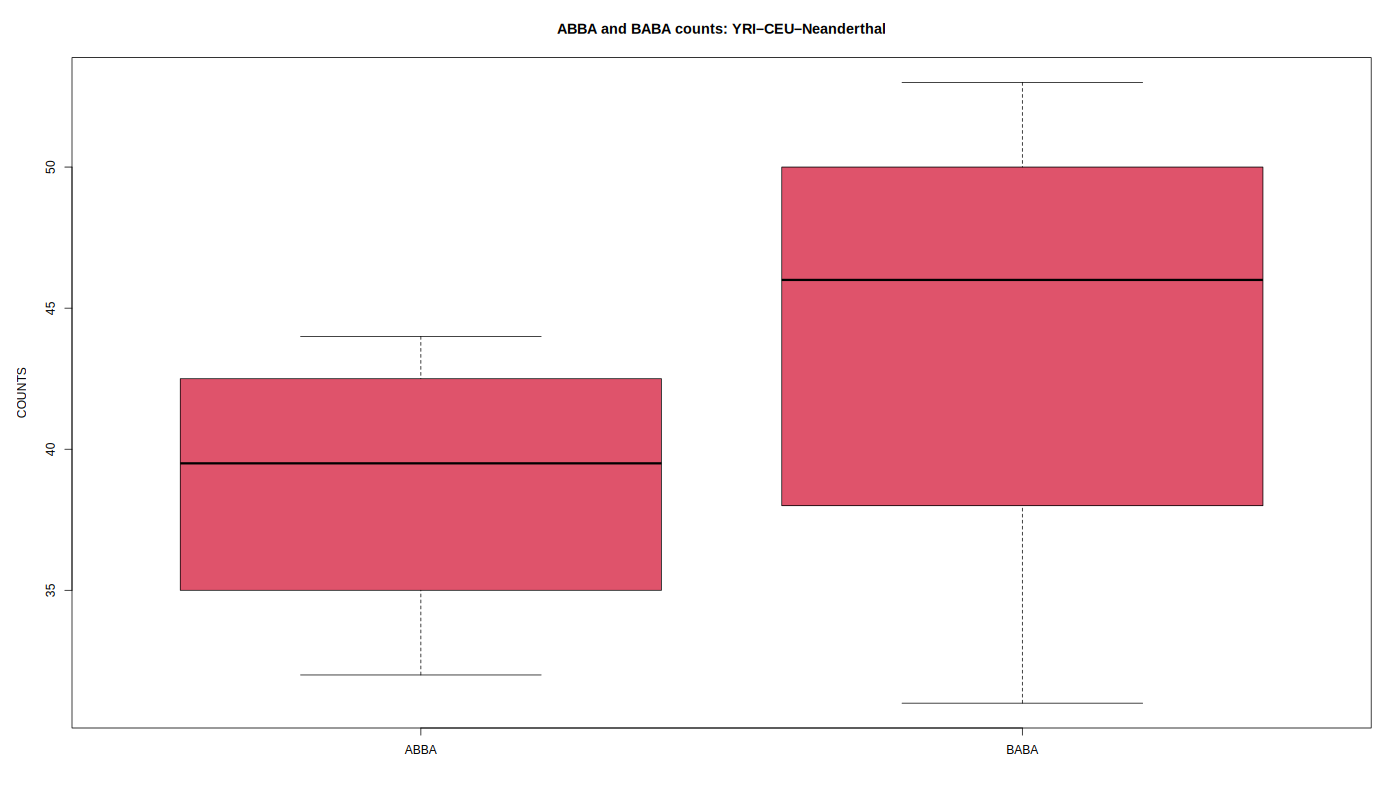

In [25]:
%%R -w 1400 -h 800 -u px

NEAND_DIR<-"/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/"

# Make sure the expected columns are numeric
df_low_topology$nABBA <- as.numeric(df_low_topology$nABBA)
df_low_topology$nBABA <- as.numeric(df_low_topology$nBABA)

png(
  filename = file.path(as.character(NEAND_DIR), "lowcov_ABBA_BABA_boxplot.png"),
  width = 1400, height = 800, res = 120
)

par(mar = c(5, 5, 4, 2))

boxplot(
  df_low_topology$nABBA,
  df_low_topology$nBABA,
  names = c("ABBA", "BABA"),
  ylab = "COUNTS",
  main = "ABBA and BABA counts: YRI–CEU–Neanderthal",
  col = 2
)

dev.off()

# Re-open a plotting device for inline display in Colab
par(mar = c(5, 5, 4, 2))
boxplot(
  df_low_topology$nABBA,
  df_low_topology$nBABA,
  names = c("ABBA", "BABA"),
  ylab = "COUNTS",
  main = "ABBA and BABA counts: YRI–CEU–Neanderthal",
  col = 2
)

cat("\nWilcoxon rank-sum test:\n")
print(wilcox.test(
  df_low_topology$nABBA,
  df_low_topology$nBABA
))

cat("\nSaved:", file.path(as.character(NEAND_DIR), "lowcov_ABBA_BABA_boxplot.png"), "\n")


Here we observe a very strange result that contradicts to our expectation. The BABA-scenario, i.e. Neandertal introgression to Yoruba seems to be more common than the ABBA (Neandertal to Europeans) introgression. However the Mann-Whittney U test shows a non-significant p-value suggesting that this difference should not be over-interpreted as it is not different from noise behaviour.

### 9.1 Display the D-statistic results

For each selected comparison, we display the D-statistic, jackknife estimate, standard error and Z-score. A positive D-statistic means that ABBA counts exceed BABA counts for the specified topology; statistical support is assessed using the jackknife standard error and Z-score rather than the sign alone.

                                                              H1
 small.NA18486.mapped.ILLUMINA.bwa.YRI.low_coverage.20120522.bam
 small.NA18488.mapped.ILLUMINA.bwa.YRI.low_coverage.20120522.bam
 small.NA18486.mapped.ILLUMINA.bwa.YRI.low_coverage.20120522.bam
 small.NA18488.mapped.ILLUMINA.bwa.YRI.low_coverage.20120522.bam
                                                              H2
 small.NA06984.mapped.ILLUMINA.bwa.CEU.low_coverage.20120522.bam
 small.NA06984.mapped.ILLUMINA.bwa.CEU.low_coverage.20120522.bam
 small.NA06985.mapped.ILLUMINA.bwa.CEU.low_coverage.20120522.bam
 small.NA06985.mapped.ILLUMINA.bwa.CEU.low_coverage.20120522.bam
                  H3 nABBA nBABA       Dstat     jackEst        SE           Z
 Neandertal.hg19.bam    38    45 -0.08433735 -0.08433735 0.1354023 -0.62286520
 Neandertal.hg19.bam    41    53 -0.12765960 -0.12765960 0.1067619 -1.19574100
 Neandertal.hg19.bam    32    31  0.01587302  0.01587302 0.1640075  0.09678224
 Neandertal.hg19.bam    44    47 -

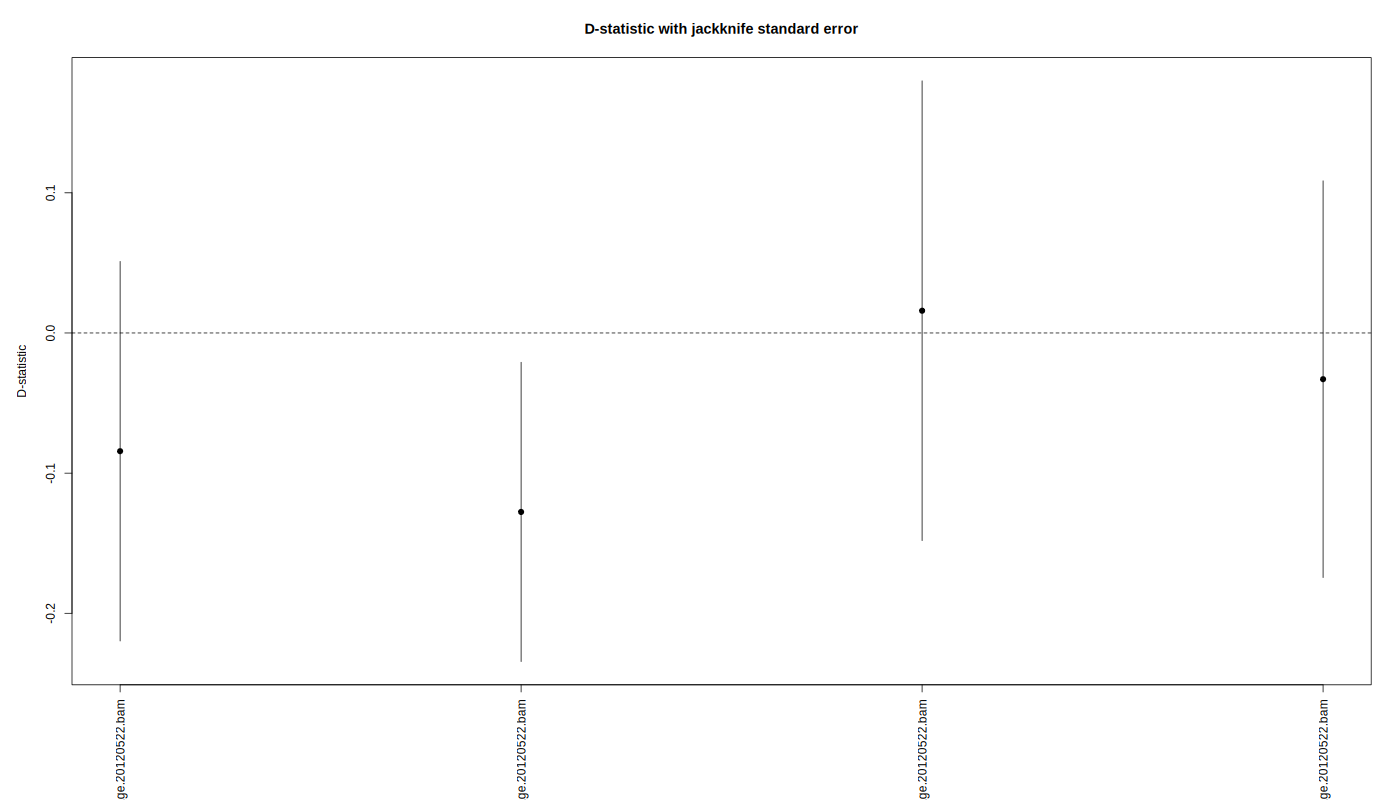

In [26]:
%%R -w 1400 -h 800 -u px

keep <- c("H1", "H2", "H3", "nABBA", "nBABA",
          "Dstat", "jackEst", "SE", "Z")

print(df_low_topology[, intersect(keep, colnames(df_low_topology))],
      row.names = FALSE)

# Plot D-statistics with jackknife SE
d <- as.numeric(df_low_topology$Dstat)
se <- as.numeric(df_low_topology$SE)

png(
  filename = file.path(as.character(NEAND_DIR_R), "lowcov_Dstat_SE.png"),
  width = 1400, height = 800, res = 120
)

par(mar = c(8, 5, 4, 2))
plot(
  seq_along(d), d,
  pch = 19,
  xaxt = "n",
  ylim = range(c(d - se, d + se, 0), na.rm = TRUE),
  xlab = "",
  ylab = "D-statistic",
  main = "D-statistic with jackknife standard error"
)
segments(seq_along(d), d - se, seq_along(d), d + se)
abline(h = 0, lty = 2)

axis(
  1,
  at = seq_along(d),
  labels = paste(df_low_topology$H1,
                 df_low_topology$H2,
                 sep = " / "),
  las = 2
)

dev.off()

# Inline display
par(mar = c(8, 5, 4, 2))
plot(
  seq_along(d), d,
  pch = 19,
  xaxt = "n",
  ylim = range(c(d - se, d + se, 0), na.rm = TRUE),
  xlab = "",
  ylab = "D-statistic",
  main = "D-statistic with jackknife standard error"
)
segments(seq_along(d), d - se, seq_along(d), d + se)
abline(h = 0, lty = 2)
axis(
  1,
  at = seq_along(d),
  labels = paste(df_low_topology$H1,
                 df_low_topology$H2,
                 sep = " / "),
  las = 2
)

cat("\nSaved:", file.path(as.character(NEAND_DIR_R), "lowcov_Dstat_SE.png"), "\n")


Again, what we observe here is that only for one out of four pairwise comparisons, the D-statistic is positive, which is our expectation since we believe that the introgression happened from Neandertals to CEU and not YRI. Still, please note that none of the 4 computed D-statistics is statistically significant (neither positive or negative), which again suggests that this result is not statistically robust and should not be interpreted at all.

This example demonstrates the artifact of low-coverage files being used for genetic analysis. We will proceed with high-coverage filess below and demonstrate the statistically significant positive D-statistic.

## 10. High-coverage genomes: Yoruba, French and Neanderthal

The low-coverage 1000 Genomes data contain relatively few usable observations per site compared with high-coverage whole genomes. We therefore repeat the ABBA-BABA analysis with the three high-coverage genomes which were used for the original Green at al., Nature 2010, drafet Neandetal genome analysis:

- `Yoruba.bam`
- `French.bam`
- `Neanderthal.bam`

All three BAM files are located in:

`/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/hg18`

We create a three-line BAM list in the order:

```text
Yoruba.bam
French.bam
Neanderthal.bam
```

With these three genomes, ANGSD evaluates the possible three-individual configurations. The first configuration corresponds to:

**(Yoruba, French, Neanderthal; chimpanzee)**

which is the topology used to illustrate Neanderthal gene flow into modern Europeans.

In [ ]:
HIGHCOV_BAMS = NEAND_DIR / "highcov_bams"

for p in [YORUBA_BAM, FRENCH_BAM, NEAND_BAM]:
    if not p.exists():
        raise FileNotFoundError(f"Missing high-coverage BAM: {p}")

with open(HIGHCOV_BAMS, "w") as f:
    f.write(str(YORUBA_BAM) + "\n")
    f.write(str(FRENCH_BAM) + "\n")
    f.write(str(NEAND_BAM) + "\n")

print(HIGHCOV_BAMS)
print(HIGHCOV_BAMS.read_text())

/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/highcov_bams
/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/hg18/Yoruba.bam
/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/hg18/French.bam
/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/hg18/Neandertal.bam



### 10.1 Run ANGSD for the three high-coverage genomes

This is the three-genome version of the command shown in the first slide:

```bash
angsd -out highcov_abbababa -doAbbababa 1 -bam highcov_bams -doCounts 1 -anc anc.fa
```

The output is again written to the `Neanderthal` directory.

In [ ]:
HIGHCOV_OUT = NEAND_DIR / "highcov_abbababa"

cmd = [
    "angsd",
    "-out", str(HIGHCOV_OUT),
    "-doAbbababa", "1",
    "-bam", str(HIGHCOV_BAMS),
    "-doCounts", "1",
    "-anc", str(ANC_FA)
]

print("Running:")
print(" ".join(cmd))

subprocess.run(cmd, check=True)

print("\nHigh-coverage ANGSD analysis completed.")

Running:
angsd -out /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/highcov_abbababa -doAbbababa 1 -bam /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/highcov_bams -doCounts 1 -anc /content/drive/MyDrive/PopGen_PopStructure/1000G/anc.fa


CalledProcessError: Command '['angsd', '-out', '/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/highcov_abbababa', '-doAbbababa', '1', '-bam', '/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/highcov_bams', '-doCounts', '1', '-anc', '/content/drive/MyDrive/PopGen_PopStructure/1000G/anc.fa']' returned non-zero exit status 1.

In [ ]:
!angsd \
-i /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/hg18/Yoruba_rewritten.bam \
-doCounts 1 \
-out /content/test_yoruba

	-> angsd version: 0.940-dirty (htslib: 1.23.1) build(Dec 15 2024 09:11:59)
	-> angsd -i /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/hg18/Yoruba.bam -doCounts 1 -out /content/test_yoruba 
	-> Inputtype is BAM/CRAM
	-> No header information could be found for BAM/CRAM file: '/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/hg18/Yoruba.bam' will exit


In [ ]:
!angsd -out /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/highcov_abbababa -doAbbababa 1 -bam /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/highcov_bams -doCounts 1 -anc /content/drive/MyDrive/PopGen_PopStructure/1000G/anc.fa

	-> angsd version: 0.940-dirty (htslib: 1.23.1) build(Dec 15 2024 09:11:59)
	-> angsd -out /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/highcov_abbababa -doAbbababa 1 -bam /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/highcov_bams -doCounts 1 -anc /content/drive/MyDrive/PopGen_PopStructure/1000G/anc.fa 
	-> Inputtype is BAM/CRAM
	-> No header information could be found for BAM/CRAM file: '/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/hg18/Yoruba.bam' will exit


In [ ]:
!cat /content/drive/MyDrive/PopGen_PopStructure/Neanderthal/highcov_bams

/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/hg18/Yoruba.bam
/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/hg18/French.bam
/content/drive/MyDrive/PopGen_PopStructure/Neanderthal/hg18/Neandertal.bam


### 10.2 Jackknife for the high-coverage genomes

We use the same `jackKnife.R` script, but now with the three-genome BAM list.

In [ ]:
HIGHCOV_JK_OUT = NEAND_DIR / "highcov_abbababa_results"

cmd = [
    "Rscript",
    str(JACKKNIFE_R),
    f"file={HIGHCOV_OUT}.abbababa",
    f"indNames={HIGHCOV_BAMS}",
    f"outfile={HIGHCOV_JK_OUT}"
]

print("Running:")
print(" ".join(cmd))

subprocess.run(cmd, check=True)

possible_high = [
    NEAND_DIR / "highcov_abbababa_results.txt",
    NEAND_DIR / "highcov_abbababa_results"
]
HIGHCOV_RESULTS = next((p for p in possible_high if p.exists()), None)

if HIGHCOV_RESULTS is None:
    raise FileNotFoundError("High-coverage jackknife output was not found.")

print("\nResult file:", HIGHCOV_RESULTS)
print(HIGHCOV_RESULTS.read_text()[:5000])

## 11. Visualize the high-coverage D-statistics in R

For the three high-coverage genomes there are only three possible three-individual configurations. The first line corresponds to:

**Yoruba – French – Neanderthal**

and is the topology relevant to testing whether Neanderthal shares more derived alleles with French than with Yoruba.

We plot all three D-statistics with their jackknife standard errors.

In [ ]:
df_high = pd.read_csv(HIGHCOV_RESULTS, sep="\t")
display(df_high)

In [ ]:
NEAND_DIR_R = str(NEAND_DIR)
%R -i df_high -i NEAND_DIR_R

In [ ]:
%%R -w 1400 -h 800 -u px

df_high$Dstat <- as.numeric(df_high$Dstat)
df_high$SE <- as.numeric(df_high$SE)

x <- seq_len(nrow(df_high))
y <- df_high$Dstat
se <- df_high$SE

labels <- paste(df_high$H1, df_high$H2, df_high$H3, sep = " / ")

# Save a high-resolution PNG
png(
  filename = file.path(as.character(NEAND_DIR_R), "highcov_Dstat_SE.png"),
  width = 1400, height = 800, res = 120
)

par(mar = c(9, 5, 4, 2))

plot(
  x, y,
  pch = 19,
  xaxt = "n",
  ylim = range(c(y - se, y + se, 0), na.rm = TRUE),
  xlab = "",
  ylab = "D-statistic",
  main = "D-statistics: high-coverage genomes"
)

segments(x, y - se, x, y + se)
abline(h = 0, lty = 2)
axis(1, at = x, labels = labels, las = 2)

dev.off()

# Inline display
par(mar = c(9, 5, 4, 2))

plot(
  x, y,
  pch = 19,
  xaxt = "n",
  ylim = range(c(y - se, y + se, 0), na.rm = TRUE),
  xlab = "",
  ylab = "D-statistic",
  main = "D-statistics: high-coverage genomes"
)

segments(x, y - se, x, y + se)
abline(h = 0, lty = 2)
axis(1, at = x, labels = labels, las = 2)

cat("\nSaved:", file.path(as.character(NEAND_DIR_R), "highcov_Dstat_SE.png"), "\n")


## 12. Interpreting the high-coverage result

For the topology:

**(Yoruba, French, Neanderthal; chimpanzee)**

a positive D-statistic indicates an excess of ABBA relative to BABA patterns under the allele-polarization convention used by the analysis.

The magnitude of the D-statistic and its uncertainty should be considered together. In the course example, the high number of genomic sites produces a much smaller jackknife standard error than in the low-coverage example, giving a much larger absolute Z-score.

A statistically supported positive D-statistic for the Yoruba–French–Neanderthal topology is consistent with gene flow between Neanderthals and the French/European lineage. The D-statistic itself does not identify the direction or exact timing of gene flow, and the test is sensitive to the assumed topology and outgroup.

## 13. Files generated by this notebook

All analysis outputs are stored in:

`/content/drive/MyDrive/PopGen_PopStructure/Neanderthal`

Important files include:

- `bams` — low-coverage Neanderthal + YRI + CEU BAM list
- `out_abbababa.abbababa` — low-coverage ANGSD ABBA-BABA block output
- `out_abbababa_results.txt` — low-coverage jackknife results
- `highcov_bams` — three-genome high-coverage BAM list
- `highcov_abbababa.abbababa` — high-coverage ANGSD ABBA-BABA block output
- `highcov_abbababa_results.txt` — high-coverage jackknife results
- `jackKnife.R` — the jackknife script supplied in the course data directory

## 14. Summary

In this notebook we:

- installed ANGSD in Google Colab;
- enabled R through rpy2 `%%R` magic;
- assembled full-path BAM lists from the Google Drive;
- ran ANGSD `-doAbbababa 1` on low-coverage 1000 Genomes samples;
- used the supplied `jackKnife.R` script to obtain D-statistics, standard errors and Z-scores;
- visualized ABBA/BABA counts and D-statistics in R;
- repeated the analysis with high-coverage Yoruba, French and Neanderthal genomes;
- compared the precision of the low- and high-coverage analyses.

### References

Korneliussen, T. S., Albrechtsen, A., & Nielsen, R. (2014). ANGSD: Analysis of Next Generation Sequencing Data. *BMC Bioinformatics*.

ANGSD documentation: ABBA-BABA / D-statistic analysis.

In [29]:
!jupyter nbconvert --to html /content/drive/MyDrive/PopGen_PopStructure/Dstat_ABBA_BABA_Colab.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/PopGen_PopStructure/Dstat_ABBA_BABA_Colab.ipynb to html
/usr/local/share/jupyter/nbconvert/templates/base/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['application/vnd.colab-display-data+json']) is not able to be represented.
  {%- elif type == 'text/vnd.mermaid' -%}
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 465185 bytes to /content/drive/MyDrive/PopGen_PopStructure/Dstat_ABBA_BABA_Colab.html
